# 🎯 HCVRPTW Step-by-Step Evaluation (Inference) Analysis
Notebook ini dikhususkan untuk membedah file `eval.py`. Anda dapat melihat bagaimana model mengambil keputusan secara detail step-by-step setelah proses training selesai.

In [1]:
# 1. Setup Environment (Hanya untuk Google Colab)
# Uncomment baris di bawah ini jika baru pertama clone di Colab
# !git clone https://github.com/your-repo/routing-optim.git
# %cd routing-optim/fleet_v3_gcollab
# !pip install -r ../requirements.txt

## 📚 1. Import Dependencies

In [2]:
import os
import torch
from torch.utils.data import DataLoader
import math

# Fallback progress bar jika jupyter/ipywidgets error atau tidak terinstal
try:
    from tqdm.notebook import tqdm
    tqdm(range(0)).close()
except (ImportError, NameError, Exception):
    from tqdm import tqdm

# Import struktur internal
from core.problems import HCVRP
from utils import load_model, move_to
from core.nets.attention_model import set_decode_type

Exception ignored in: <function tqdm.__del__ at 0x00000130F0730CC0>
Traceback (most recent call last):
  File "c:\Users\kevin.kurniawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\kevin.kurniawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


## ⚙️ 2. Konfigurasi Evaluasi & Load Dataset
Kita definisikan parameter dasar untuk evaluasi (batch size, device) dan membuat ulang dataset HCVRPTW (atau load dari pkl).

In [ ]:
class EvalOptions:
    pass
opts = EvalOptions()

opts.use_cuda = torch.cuda.is_available()
opts.device = torch.device('cuda:0' if opts.use_cuda else 'cpu')
opts.eval_batch_size = 4
opts.graph_size = 40
opts.val_size = 16 

print(f"Menggunakan Device: {opts.device}")

problem = HCVRP()

# =====================================================================
# PILIHAN DATASET EVALUASI:
# Pilihan 1: Load dataset dari file .pkl yang sudah ada (Rekomendasi untuk benchmark)
# Pilihan 2: Generate dataset dummy baru secara acak (Hanya untuk testing code jalan)
# =====================================================================
# dataset_path = None  
dataset_path = 'data/hcvrp/hcvrp_40_seed24610.pkl'  
# Ganti dengan path file pkl, misal: 'data/hcvrp/hcvrp_v3_40_seed99999_tw.pkl'

if dataset_path is not None and os.path.exists(dataset_path):
    print(f"Loading dataset dari file: {dataset_path}")
    eval_dataset = problem.make_dataset(
        filename=dataset_path,
        num_samples=opts.val_size
    )
else:
    print("Membuat dataset evaluasi dummy baru...")
    eval_dataset = problem.make_dataset(
        size=opts.graph_size, 
        num_samples=opts.val_size
    )

eval_dataloader = DataLoader(eval_dataset, batch_size=opts.eval_batch_size)

# Print kapasitas kendaraan dan time window dari outlet (sebagai contoh, dari instance 0)
first_instance = eval_dataset[0]
capacities = first_instance['capacity'].tolist()
print("\n--- DETAIL KAPASITAS KENDARAAN ---")
for idx, cap in enumerate(capacities):
    print(f"  Mobil {idx + 1}: {cap} unit")

print("\n--- DETAIL TIME WINDOW OUTLET (CONTOH INSTANCE 0) ---")
time_windows = first_instance['time_window']
for node_idx in range(time_windows.size(0)):
    open_hours = [hour for hour in range(24) if time_windows[node_idx, hour] > 0.5]
    print(f"  Outlet/Customer {node_idx + 1}: Jam buka -> {open_hours}")

Menggunakan Device: cpu
Membuat dataset evaluasi dummy baru...

--- DETAIL KAPASITAS KENDARAAN ---
  Mobil 1: 20.0 unit
  Mobil 2: 25.0 unit
  Mobil 3: 30.0 unit

--- DETAIL TIME WINDOW OUTLET (CONTOH INSTANCE 0) ---
  Outlet/Customer 1: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 2: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 3: Jam buka -> [7, 8, 9, 10, 11]
  Outlet/Customer 4: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 5: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 6: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 7: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 8: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 9: Jam buka -> [7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Outlet/Customer 10: Jam buka -> [13, 14, 15, 16, 17]
  Outlet/Customer 11: Jam buka -> [7, 8, 9, 10, 11]
  Outlet/Customer 12: Jam buka -> [7, 8, 9, 10, 11, 13, 1

### 🗺️ Visualisasi Peta Depot & Outlet Sebelum Optimasi
Menampilkan sebaran lokasi geografis dari outlet dan depot berdasarkan dataset evaluasi (Instance 0).

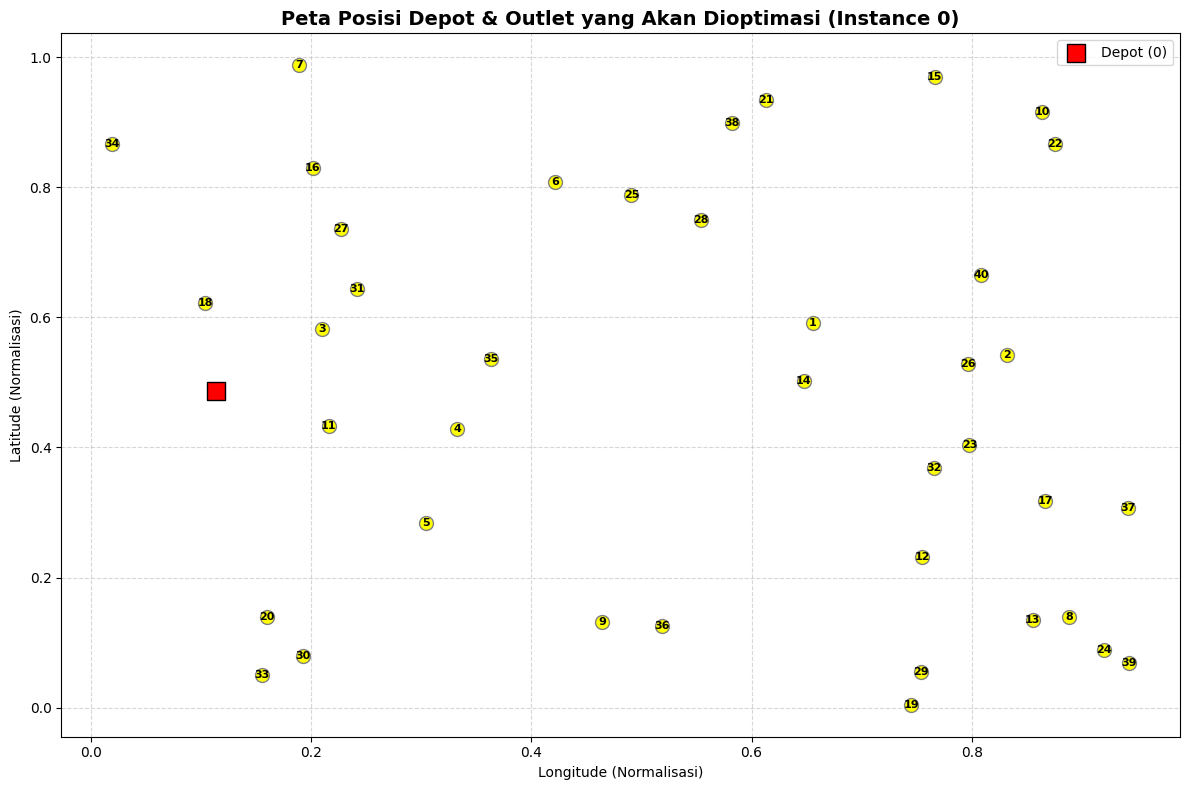

In [4]:
# --- Visualisasi Posisi Depot & Outlet Sebelum Optimasi (Instance 0) ---
import matplotlib.pyplot as plt

first_instance = eval_dataset[0]
depot_coords = first_instance['depot'].cpu().numpy() if isinstance(first_instance['depot'], torch.Tensor) else first_instance['depot']
customer_coords = first_instance['loc'].cpu().numpy() if isinstance(first_instance['loc'], torch.Tensor) else first_instance['loc']

plt.figure(figsize=(12, 8))

# Plot Depot (X = Longitude, Y = Latitude agar sesuai dengan colab_data_custom)
plt.scatter(depot_coords[1], depot_coords[0], c='red', marker='s', s=150, label='Depot (0)', zorder=5, edgecolors='black')

# Plot Customers
for num, (cx, cy) in enumerate(customer_coords, start=1):
    plt.scatter(cy, cx, c='yellow', edgecolors='gray', marker='o', s=100, zorder=4)
    plt.text(cy, cx, str(num), fontsize=8, ha='center', va='center', zorder=6, weight='bold')

plt.title('Peta Posisi Depot & Outlet yang Akan Dioptimasi (Instance 0)', fontsize=14, fontweight='bold')
plt.xlabel('Longitude (Normalisasi)', fontsize=10)
plt.ylabel('Latitude (Normalisasi)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 🤖 3. Load Model (Checkpoint)
Memanggil fungsi `load_model` untuk memuat bobot model (`.pt`) hasil training.

In [5]:
# Ganti path di bawah dengan lokasi checkpoint model Anda:
checkpoint_path = 'outputs/hcvrp_final_40/epoch-49.pt'
obj_type = 'min-max'

# Karena ini contoh tanpa checkpoint fisik, mari kita load model inisialisasi kosong
# JIKA ADA CHECKPOINT, UNCOMMENT BARIS INI:
model, _ = load_model(checkpoint_path, obj_type)

# JIKA BELUM ADA CHECKPOINT (Hanya untuk testing code jalan):
# from core.nets.attention_model import AttentionModelDecoder
# model = AttentionModelDecoder(128, 128, 'min-max', problem, n_encode_layers=3, n_paths=1)

model.to(opts.device)

# --- BAGIAN PALING PENTING DALAM EVALUASI ---
# 1. Matikan perhitungan gradient
model.eval()

# 2. Set Decode Type menjadi Deterministic (Greedy)
model.set_decode_type('greedy')

  [*] Loading model from outputs/hcvrp_final_40/epoch-49.pt


## 🔍 4. Menjalankan Inference Step-by-Step
Kita bongkar isi `_eval_dataset` dari `eval.py` agar Anda dapat melihat variabel keluaran `sequences` (Rute) dan `veh_lists` (Truk).

In [6]:
print("Memulai Evaluasi secara Greedy...")
all_costs = []
all_tours = []
all_vehicles = []

with torch.no_grad(): # Matikan gradien agar hemat RAM!
    for batch_id, batch in enumerate(tqdm(eval_dataloader, desc="Evaluasi")):
        batch = move_to(batch, opts.device)
        
        # INFERENCE: Mengambil keputusan rute
        sequences, costs, veh_lists = model.sample_many(batch, batch_rep=1, iter_rep=1)
        
        # Simpan hasilnya
        all_costs.extend(costs.cpu().tolist())
        all_tours.extend(sequences.cpu().tolist())
        all_vehicles.extend(veh_lists.cpu().tolist())
        
        # Tampilkan Contoh di Batch Pertama
        if batch_id == 0:
            print("\n--- CONTOH HASIL PREDIKSI (BATCH PERTAMA, INSTANCE 0) ---")
            print(f"Biaya Rute (Distance/Time): {costs[0].item():.3f}")
            print(f"Urutan Titik (Tour): {sequences[0].tolist()}")
            print(f"Kendaraan yang Dipilih: {veh_lists[0].tolist()}")

print(f"\nEvaluasi Selesai! Rata-rata Cost Keseluruhan: {sum(all_costs)/len(all_costs):.3f}")

Memulai Evaluasi secara Greedy...


Evaluasi:  25%|██▌       | 1/4 [00:01<00:04,  1.36s/it]


--- CONTOH HASIL PREDIKSI (BATCH PERTAMA, INSTANCE 0) ---
Biaya Rute (Distance/Time): 1.642
Urutan Titik (Tour): [1, 0, 18, 33, 30, 0, 3, 11, 0, 34, 31, 0, 16, 0, 27, 0, 7, 6, 25, 38, 21, 35, 0, 28, 15, 10, 22, 40, 5, 0, 14, 2, 26, 23, 37, 24, 39, 8, 13, 0, 32, 17, 12, 19, 29, 20, 0, 4, 36, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Kendaraan yang Dipilih: [0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Evaluasi: 100%|██████████| 4/4 [00:04<00:00,  1.15s/it]


Evaluasi Selesai! Rata-rata Cost Keseluruhan: 1.519


## 📊 5. Analisis Vechicle Assignment
Dari data `all_vehicles`, Anda bisa melihat urutan truk mana yang ditugaskan untuk mengirim barang di instance tertentu.

=== BREAKDOWN RUTE PER TIPE MOBIL ===
Tipe Mobil 1 (RED):
Depot -> C1 -> Depot
--------------------------------------------------
Tipe Mobil 2 (GREEN):
Depot
--------------------------------------------------
Tipe Mobil 3 (BLUE):
Depot -> C18 -> C33 -> C30 -> Depot -> C3 -> C11 -> Depot -> C34 -> C31 -> Depot -> C16 -> Depot -> C27 -> Depot -> C7 -> C6 -> C25 -> C38 -> C21 -> C35 -> Depot -> C28 -> C15 -> C10 -> C22 -> C40 -> C5 -> Depot -> C14 -> C2 -> C26 -> C23 -> C37 -> C24 -> C39 -> C8 -> C13 -> Depot -> C32 -> C17 -> C12 -> C19 -> C29 -> C20 -> Depot -> C4 -> C36 -> C9 -> Depot
--------------------------------------------------


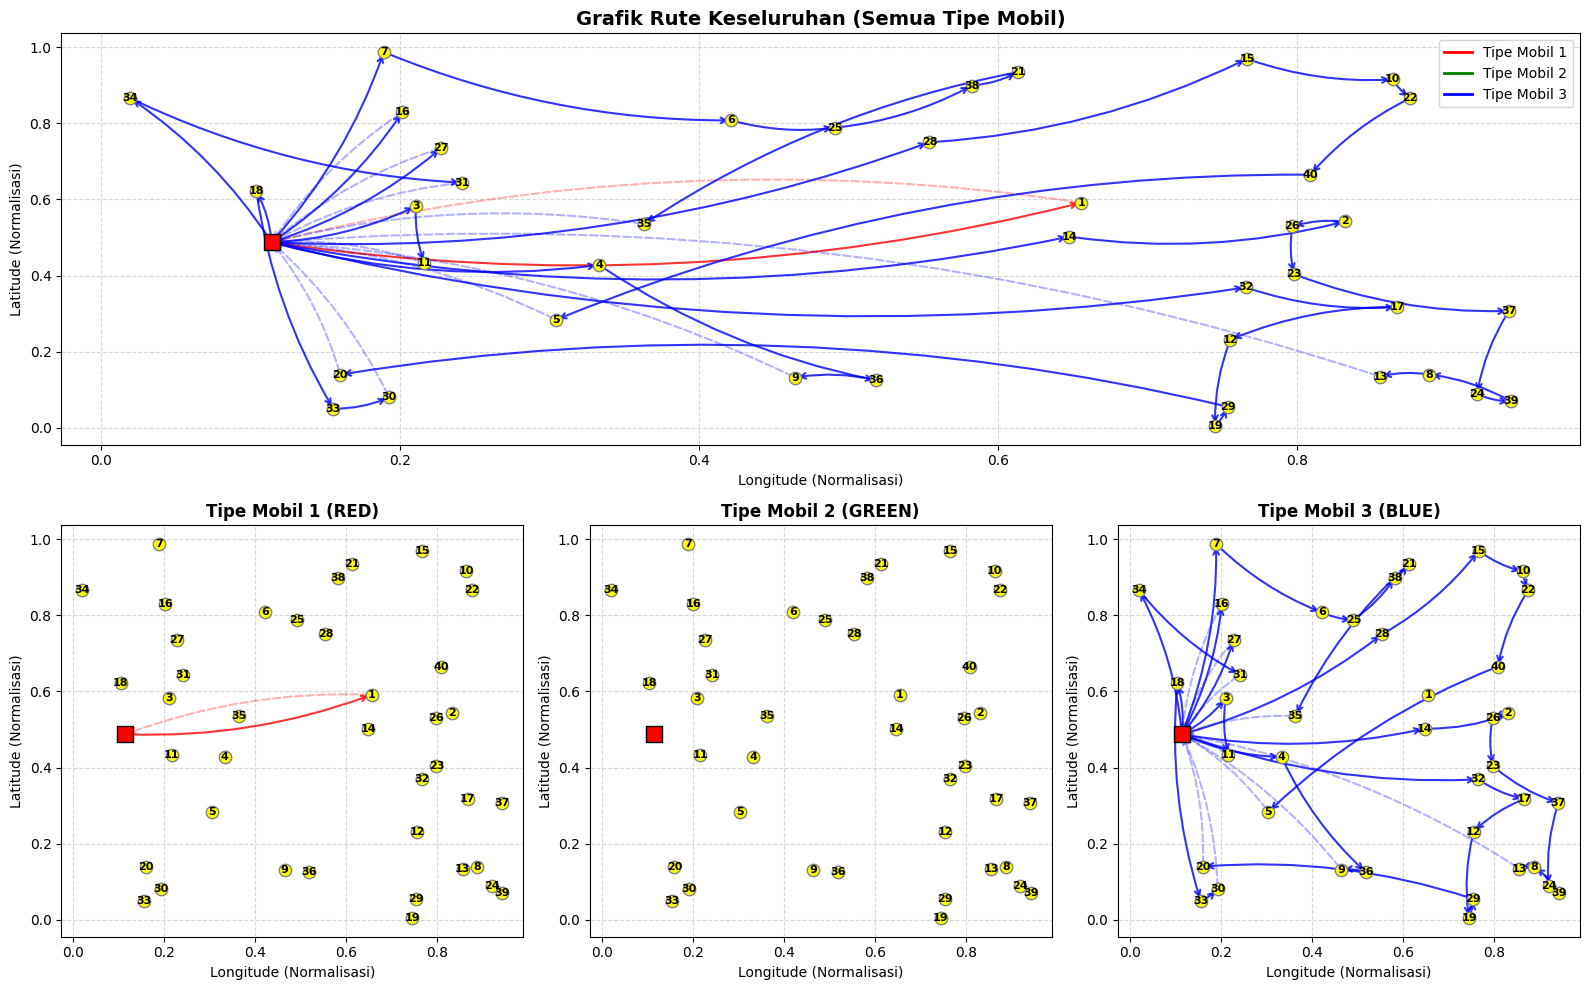

In [7]:
# --- Visualisasi Rute Hasil Evaluasi (Instance Pertama) ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np

# Mengambil data koordinat dari instance pertama
first_instance = eval_dataset[0]
depot_coords = first_instance['depot'].cpu().numpy() if isinstance(first_instance['depot'], torch.Tensor) else first_instance['depot']
customer_coords = first_instance['loc'].cpu().numpy() if isinstance(first_instance['loc'], torch.Tensor) else first_instance['loc']

tour = all_tours[0]
vehicle_tours = all_vehicles[0]

color_mapping = {0: 'red', 1: 'green', 2: 'blue'}

# Koordinat customer (X = Longitude, Y = Latitude agar sesuai dengan colab_data_custom)
x = [i[1] for i in customer_coords]
y = [i[0] for i in customer_coords]

# Masukkan koordinat depot di indeks 0
x.insert(0, depot_coords[1])
y.insert(0, depot_coords[0])

# Buat Figure dengan GridSpec untuk subplot
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Setup subplots
ax_main = fig.add_subplot(gs[0, :])
ax_v = [fig.add_subplot(gs[1, i]) for i in range(3)]
axes = [ax_main] + ax_v

# Helper function untuk menggambar titik depot dan customer di suatu axes (grafik)
def plot_base_nodes(ax):
    # Plot depot (X = Longitude, Y = Latitude agar sesuai dengan colab_data_custom)
    ax.scatter(depot_coords[1], depot_coords[0], c='red', marker='s', s=120, label='Depot (0)', zorder=5, edgecolors='black')
    
    # Plot customers
    customer_nums = range(1, len(customer_coords) + 1)
    for num, (cx, cy) in zip(customer_nums, customer_coords):
        ax.scatter(cy, cx, c='yellow', edgecolors='gray', marker='o', s=80, zorder=4)
        ax.text(cy, cx, str(num), fontsize=8, ha='center', va='center', zorder=6, weight='bold')
    
    ax.set_xlabel('Longitude (Normalisasi)', fontsize=10)
    ax.set_ylabel('Latitude (Normalisasi)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Helper function untuk menggambar rute suatu tipe mobil di axes tertentu
def draw_route(ax, v_type_color, v_tour):
    for i in range(len(v_tour) - 1):
        start_index = v_tour[i]
        end_index = v_tour[i + 1]
        
        if start_index == 0 and end_index == 0:
            continue
            
        is_return = (end_index == 0)
        alpha_val = 0.3 if is_return else 0.8
        ls_val = "dashed" if is_return else "solid"

        ax.annotate("",
            xy=(x[end_index], y[end_index]),  
            xytext=(x[start_index], y[start_index]),  
            arrowprops=dict(
                arrowstyle="->",
                color=v_type_color,
                alpha=alpha_val,
                ls=ls_val,
                connectionstyle="arc3,rad=0.1",
                lw=1.5
            ),
            zorder=3
        )

# Gambar base nodes pada semua grafik
for ax in axes:
    plot_base_nodes(ax)

ax_main.set_title('Grafik Rute Keseluruhan (Semua Tipe Mobil)', fontsize=14, fontweight='bold')

# Gambar garis rute
for v_type in sorted(color_mapping.keys()):
    v_tour = [0] + [tour[i] for i in range(len(tour)) if i < len(vehicle_tours) and vehicle_tours[i] == v_type]
    
    # RL environment secara implisit menyuruh mobil pulang ke markas di akhir proses
    if len(v_tour) > 0 and v_tour[-1] != 0:
        v_tour.append(0)
        
    arrow_color = color_mapping[v_type]
    
    # Gambar di grafik utama
    draw_route(ax_main, arrow_color, v_tour)
    
    # Gambar di grafik spesifik tipe mobil tersebut
    ax_v[v_type].set_title(f'Tipe Mobil {v_type + 1} ({arrow_color.upper()})', fontsize=12, fontweight='bold')
    draw_route(ax_v[v_type], arrow_color, v_tour)

# Legend untuk grafik utama
custom_lines = [Line2D([0], [0], color=color_mapping[k], lw=2) for k in sorted(color_mapping.keys())]
ax_main.legend(custom_lines, [f'Tipe Mobil {k+1}' for k in sorted(color_mapping.keys())], loc='upper right')

# Cetak Breakdown Rute ke Output
print("=== BREAKDOWN RUTE PER TIPE MOBIL ===")
for v_type in sorted(color_mapping.keys()):
    v_tour = [0] + [tour[i] for i in range(len(tour)) if i < len(vehicle_tours) and vehicle_tours[i] == v_type]
    
    if len(v_tour) > 0 and v_tour[-1] != 0:
        v_tour.append(0)
        
    cleaned_tour = []
    for i in range(len(v_tour)):
        if i > 0 and v_tour[i] == 0 and v_tour[i-1] == 0:
            continue
        cleaned_tour.append(v_tour[i])
        
    route_str = " -> ".join(["Depot" if n == 0 else f"C{n}" for n in cleaned_tour])
    print(f"Tipe Mobil {v_type + 1} ({color_mapping[v_type].upper()}):")
    print(route_str)
    print("-" * 50)

plt.tight_layout()
plt.show()
